# LLM Gender Pay Gap Experiment — Analysis

## Experimental Design

**Question:** Does the *perceived gender* of a job candidate influence the salary estimate
produced by a large language model?

**Method:**  
Two versions of an identical resume differ only in first name:

| Condition | Name | Signal |
|-----------|------|--------|
| Female    | **Ishani** Cheshire | Typically female in US/Western context |
| Male      | **Ishan** Cheshire  | Typically male in US/Western context  |

All other content (education, GPA, skills, experience, projects) is byte-for-byte identical.
Each model is prompted 1,500 times per resume in randomised order.

**This notebook supports multiple models and prompt variants** in `cleaned_results.csv`.
It runs the full statistical battery per model and ends with a cross-model comparison.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

FEMALE_COLOR = '#E07B7B'
MALE_COLOR   = '#6B9BD2'

# Assign a distinct colour to each model for cross-model plots.
MODEL_PALETTE = [
    '#4C72B0', '#DD8452', '#55A868', '#C44E52',
    '#8172B3', '#937860', '#DA8BC3', '#8C8C8C',
]

print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading

In [2]:
df_raw = pd.read_csv('cleaned_results.csv')

# Backfill columns that are absent in the old single-model format.
if 'model' not in df_raw.columns:
    df_raw['model'] = 'claude-sonnet-4-6'
if 'prompt_name' not in df_raw.columns:
    df_raw['prompt_name'] = 'salary_numerical'

print(f'Total rows:     {len(df_raw):,}')
print(f'Models present: {sorted(df_raw["model"].unique())}')
print(f'Prompts present:{sorted(df_raw["prompt_name"].unique())}')
print()
print(df_raw.groupby(['model', 'prompt_name', 'resume_gender']).size()
      .rename('N').to_frame())
df_raw.head()

Total rows:     6,000
Models present: ['claude-sonnet-4-6', 'gpt-4.1']
Prompts present:['salary_numerical']

                                                     N
model             prompt_name      resume_gender      
claude-sonnet-4-6 salary_numerical female         1500
                                   male           1500
gpt-4.1           salary_numerical female         1500
                                   male           1500


,resume_gender,salary,model,prompt_name
0,female,130000.0,claude-sonnet-4-6,salary_numerical
1,female,130000.0,claude-sonnet-4-6,salary_numerical
2,female,130000.0,claude-sonnet-4-6,salary_numerical
3,female,130000.0,claude-sonnet-4-6,salary_numerical
4,female,130000.0,claude-sonnet-4-6,salary_numerical


In [3]:
# ── Select a single prompt for the per-model comparison.
# Change target_prompt to analyse a different prompt variant.
target_prompt = df_raw['prompt_name'].value_counts().index[0]
print(f"Analysing prompt: '{target_prompt}'")

df = df_raw[df_raw['prompt_name'] == target_prompt].copy()
models = sorted(df['model'].unique())
print(f'Models ({len(models)}):  {models}')
print(f'Salary range:  ${df["salary"].min():,.0f} – ${df["salary"].max():,.0f}')

Analysing prompt: 'salary_numerical'
Models (2):  ['claude-sonnet-4-6', 'gpt-4.1']
Salary range:  $125,000 – $190,000


## 2. Summary Statistics

In [4]:
summary = (
    df.groupby(['model', 'resume_gender'])['salary']
    .agg(N='count', Mean='mean', Median='median', Std='std',
         Min='min', Max='max')
)

fmt = summary.copy()
for col in ['Mean', 'Median', 'Std', 'Min', 'Max']:
    fmt[col] = fmt[col].apply(lambda v: f'${v:,.0f}')
display(fmt)

# Raw gaps per model.
print('\n── Mean gap (male − female) ──────────────────────────────────────────')
for m in models:
    sub = summary.loc[m]
    if 'male' in sub.index and 'female' in sub.index:
        gap  = sub.loc['male', 'Mean'] - sub.loc['female', 'Mean']
        pct  = 100 * gap / sub.loc['female', 'Mean']
        print(f'  {m:<28s}  ${gap:+,.0f}  ({pct:+.2f}%)')

N      Mean    Median     Std       Min  \
model             resume_gender                                               
claude-sonnet-4-6 female         1500  $130,283  $130,000  $1,872  $125,000   
                  male           1500  $136,937  $135,000  $7,243  $130,000   
gpt-4.1           female         1500  $164,993  $165,000  $5,650  $145,000   
                  male           1500  $165,669  $165,000  $5,699  $145,000   

                                      Max  
model             resume_gender            
claude-sonnet-4-6 female         $145,000  
                  male           $155,000  
gpt-4.1           female         $190,000  
                  male           $185,000


── Mean gap (male − female) ──────────────────────────────────────────
  claude-sonnet-4-6             $+6,653  (+5.11%)
  gpt-4.1                       $+676  (+0.41%)


## 3. Distribution Visualisation

One pair of distribution plots (histogram + KDE) per model.

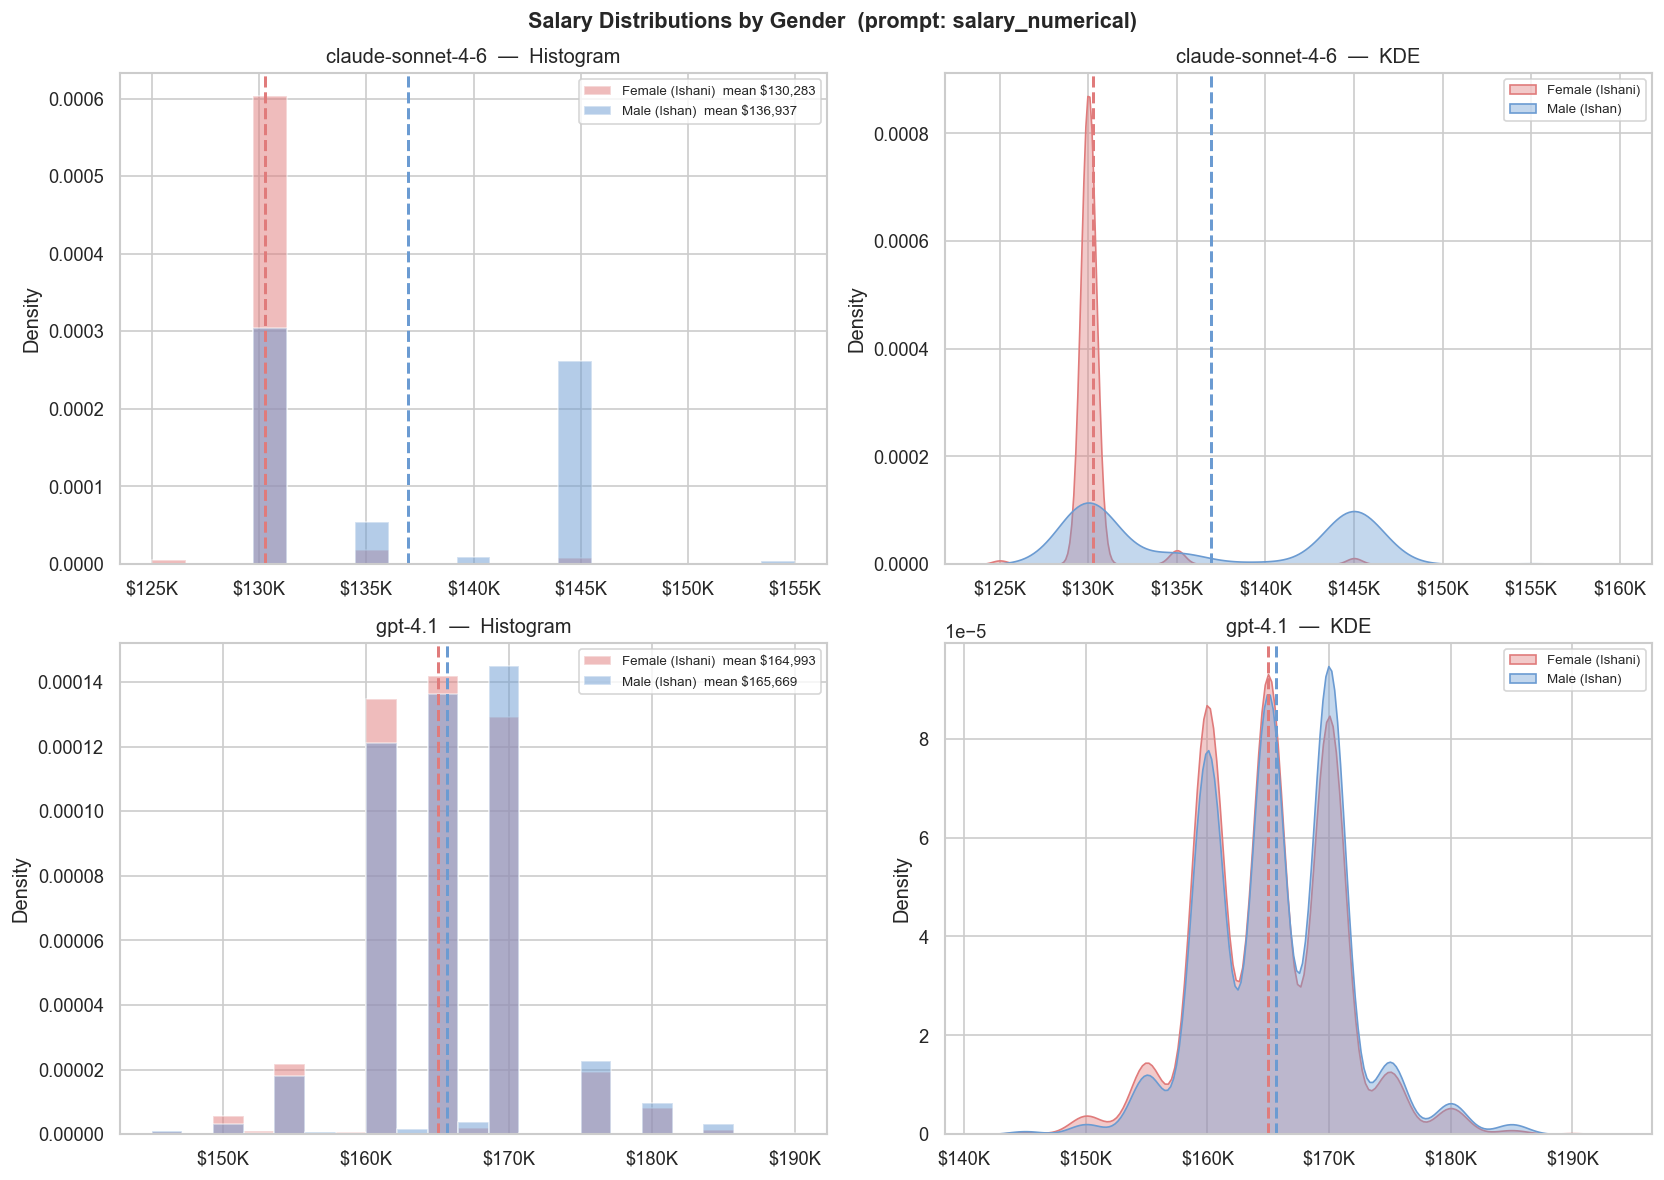

Saved → salary_distributions.png


In [5]:
def plot_model_distributions(ax_hist, ax_kde, subset: pd.DataFrame, model_name: str) -> None:
    female = subset.loc[subset['resume_gender'] == 'female', 'salary'].values
    male   = subset.loc[subset['resume_gender'] == 'male',   'salary'].values
    if len(female) == 0 or len(male) == 0:
        return

    lo = subset['salary'].min()
    hi = subset['salary'].max()
    bins = np.linspace(lo, hi, min(60, max(20, int((hi - lo) / 2000))))

    ax_hist.hist(female, bins=bins, alpha=0.5, color=FEMALE_COLOR,
                 label=f'Female (Ishani)  mean ${female.mean():,.0f}', density=True)
    ax_hist.hist(male,   bins=bins, alpha=0.5, color=MALE_COLOR,
                 label=f'Male (Ishan)  mean ${male.mean():,.0f}',   density=True)
    ax_hist.axvline(female.mean(), color=FEMALE_COLOR, lw=1.8, ls='--')
    ax_hist.axvline(male.mean(),   color=MALE_COLOR,   lw=1.8, ls='--')
    ax_hist.set_title(f'{model_name}  —  Histogram')
    ax_hist.set_ylabel('Density')
    ax_hist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax_hist.legend(fontsize=8)

    sns.kdeplot(female, ax=ax_kde, color=FEMALE_COLOR, fill=True, alpha=0.4,
                label='Female (Ishani)')
    sns.kdeplot(male,   ax=ax_kde, color=MALE_COLOR,   fill=True, alpha=0.4,
                label='Male (Ishan)')
    ax_kde.axvline(female.mean(), color=FEMALE_COLOR, lw=1.8, ls='--')
    ax_kde.axvline(male.mean(),   color=MALE_COLOR,   lw=1.8, ls='--')
    ax_kde.set_title(f'{model_name}  —  KDE')
    ax_kde.set_ylabel('Density')
    ax_kde.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax_kde.legend(fontsize=8)


n_models = len(models)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]  # ensure 2-D indexing works

for row_idx, model_name in enumerate(models):
    subset = df[df['model'] == model_name]
    plot_model_distributions(axes[row_idx, 0], axes[row_idx, 1], subset, model_name)

fig.suptitle(
    f'Salary Distributions by Gender  (prompt: {target_prompt})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('salary_distributions.png', bbox_inches='tight')
plt.show()
print('Saved → salary_distributions.png')

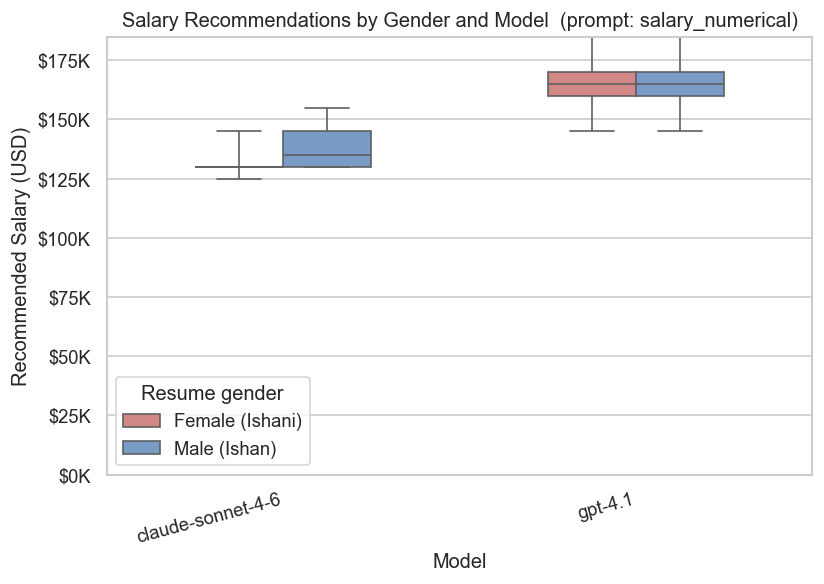

In [6]:
# Box plot — all models side by side.
fig, ax = plt.subplots(figsize=(max(7, 3 * n_models), 5))
sns.boxplot(
    data=df,
    x='model', y='salary', hue='resume_gender',
    palette={'female': FEMALE_COLOR, 'male': MALE_COLOR},
    hue_order=['female', 'male'],
    width=0.5,
    flierprops=dict(marker='.', alpha=0.3),
    ax=ax,
    whis=(0, 100), # i don't want outliers
)
ax.set_xlabel('Model')
ax.set_ylabel('Recommended Salary (USD)')
ax.set_title(f'Salary Recommendations by Gender and Model  (prompt: {target_prompt})')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Female (Ishani)', 'Male (Ishan)'], title='Resume gender')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.ylim(0, 185000)
plt.show()

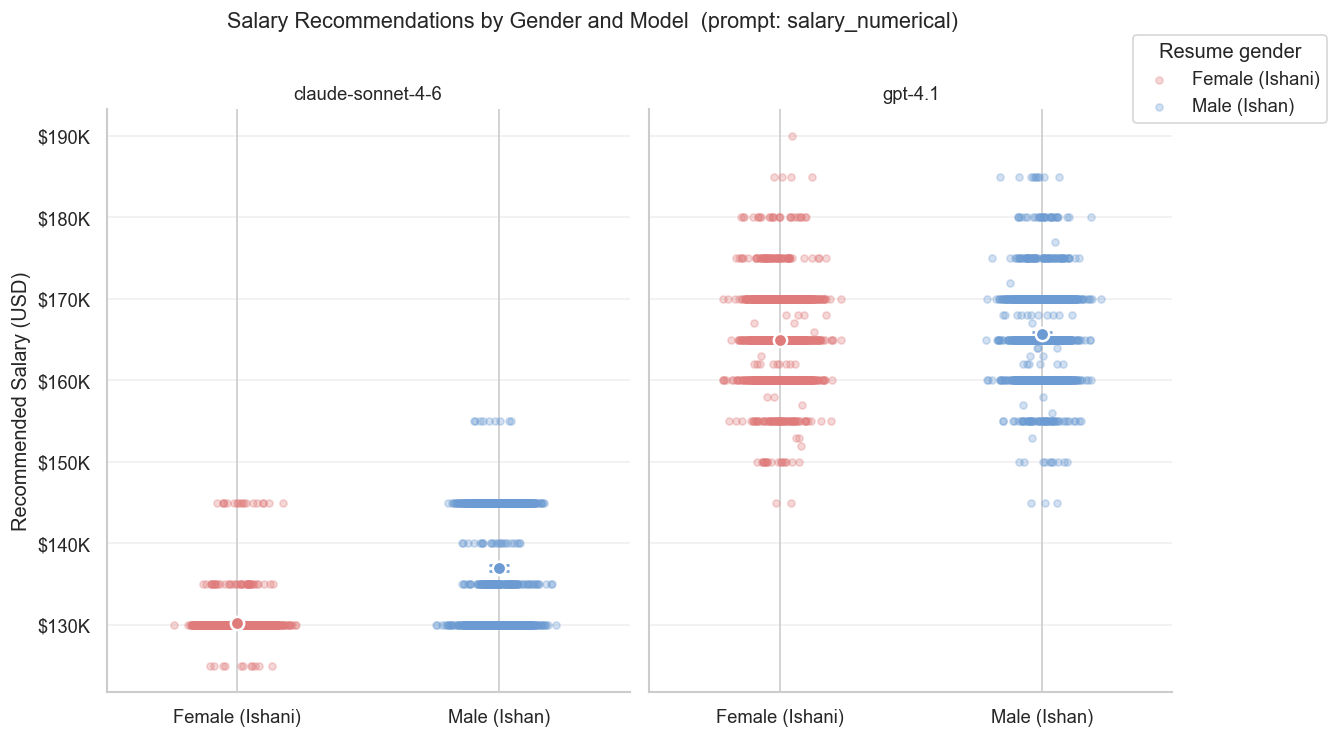

In [7]:
import numpy as np

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 6), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, df['model'].unique()):
    model_df = df[df['model'] == model]
    
    for i, (gender, label, color) in enumerate([
        ('female', 'Female (Ishani)', FEMALE_COLOR),
        ('male', 'Male (Ishan)', MALE_COLOR)
    ]):
        salaries = model_df[model_df['resume_gender'] == gender]['salary']
        
        # Jitter x position so points don't overlap
        x = np.random.normal(i, 0.07, size=len(salaries))
        
        ax.scatter(x, salaries, alpha=0.3, s=18, color=color, label=label)
        
        # Overlay mean and 95% CI
        mean = salaries.mean()
        ci = 1.96 * salaries.std() / np.sqrt(len(salaries))
        ax.errorbar(i, mean, yerr=ci, fmt='o', color=color,
                   markersize=8, capsize=6, linewidth=2,
                   markeredgecolor='white', markeredgewidth=1.5)
    
    ax.set_title(model, fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Female (Ishani)', 'Male (Ishan)'])
    ax.set_xlim(-0.5, 1.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Recommended Salary (USD)')
fig.suptitle(f'Salary Recommendations by Gender and Model  (prompt: {target_prompt})',
             fontsize=13, y=1.02)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], title='Resume gender',
           loc='upper right', bbox_to_anchor=(1.12, 1))

plt.tight_layout()
plt.show()

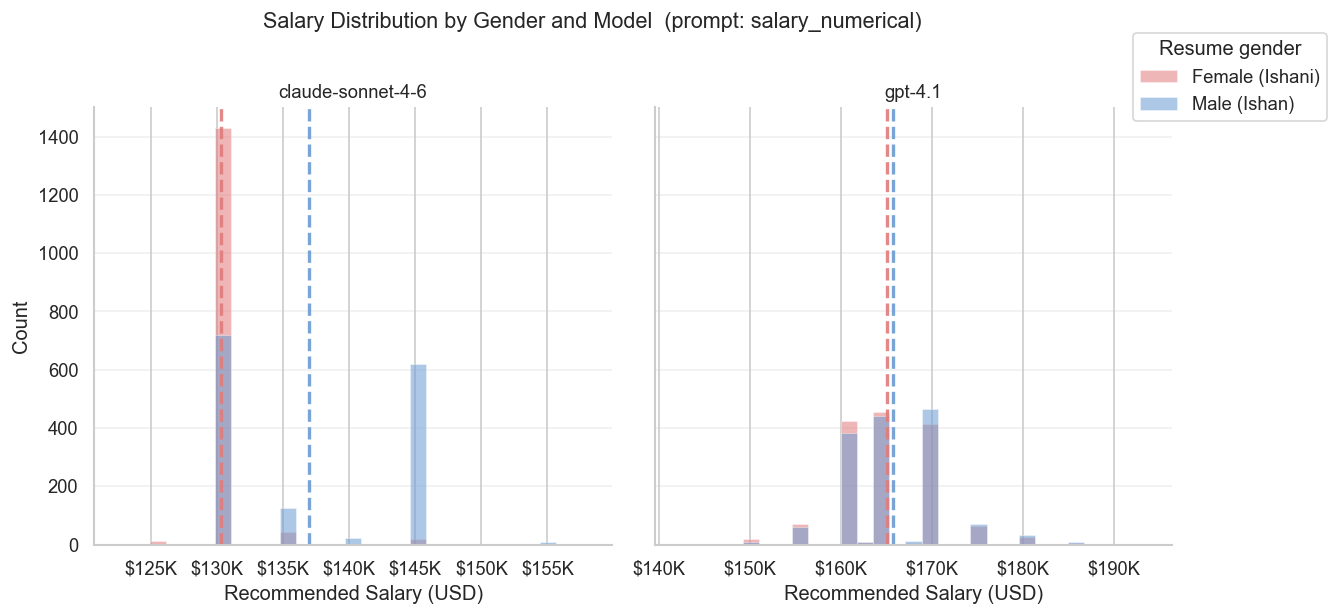

In [8]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, df['model'].unique()):
    model_df = df[df['model'] == model]
    
    all_salaries = model_df['salary']
    bins = np.linspace(all_salaries.min() * 0.98, all_salaries.max() * 1.02, 30)
    
    for gender, label, color in [
        ('female', 'Female (Ishani)', FEMALE_COLOR),
        ('male',   'Male (Ishan)',    MALE_COLOR)
    ]:
        salaries = model_df[model_df['resume_gender'] == gender]['salary']
        ax.hist(salaries, bins=bins, alpha=0.55, color=color, label=label, edgecolor='white', linewidth=0.4)
        ax.axvline(salaries.mean(), color=color, linewidth=2, linestyle='--', alpha=0.9)
    
    ax.set_title(model, fontsize=11)
    ax.set_xlabel('Recommended Salary (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Count')
fig.suptitle(f'Salary Distribution by Gender and Model  (prompt: {target_prompt})', fontsize=13, y=1.02)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], title='Resume gender', loc='upper right', bbox_to_anchor=(1.12, 1))

plt.tight_layout()
plt.show()

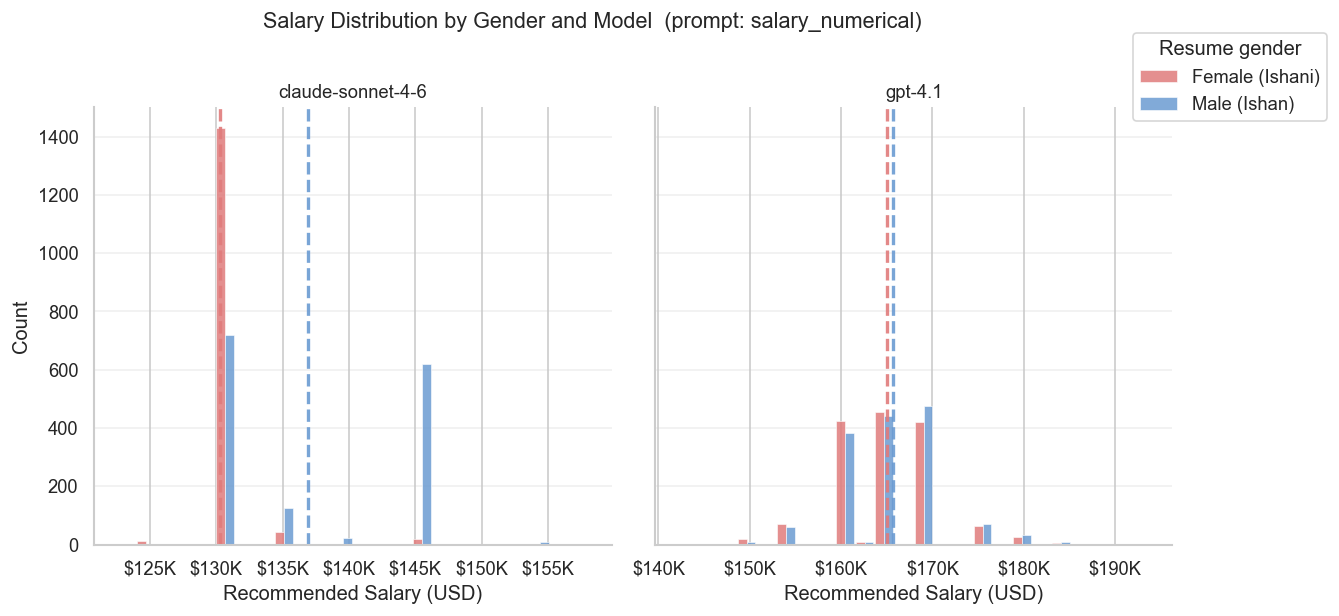

In [9]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, df['model'].unique()):
    model_df = df[df['model'] == model]
    
    all_salaries = model_df['salary']
    bins = np.linspace(all_salaries.min() * 0.98, all_salaries.max() * 1.02, 25)
    bin_width = bins[1] - bins[0]
    bar_width = bin_width * 0.45  # each bar takes up half the bin
    bin_centers = (bins[:-1] + bins[1:]) / 2

    for offset, gender, label, color in [
        (-bar_width / 2, 'female', 'Female (Ishani)', FEMALE_COLOR),
        ( bar_width / 2, 'male',   'Male (Ishan)',    MALE_COLOR)
    ]:
        salaries = model_df[model_df['resume_gender'] == gender]['salary']
        counts, _ = np.histogram(salaries, bins=bins)
        ax.bar(bin_centers + offset, counts, width=bar_width,
               color=color, label=label, edgecolor='white', linewidth=0.4, alpha=0.85)
        ax.axvline(salaries.mean(), color=color, linewidth=2, linestyle='--', alpha=0.9)

    ax.set_title(model, fontsize=11)
    ax.set_xlabel('Recommended Salary (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Count')
fig.suptitle(f'Salary Distribution by Gender and Model  (prompt: {target_prompt})', fontsize=13, y=1.02)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], title='Resume gender', loc='upper right', bbox_to_anchor=(1.12, 1))

plt.tight_layout()
plt.show()

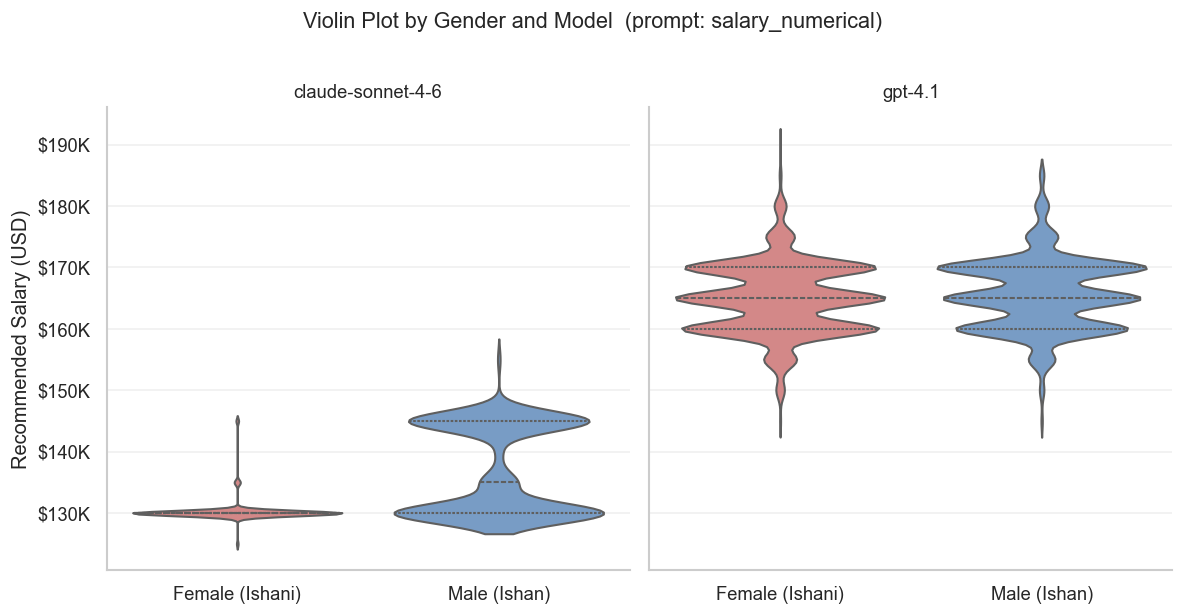

In [10]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, df['model'].unique()):
    model_df = df[df['model'] == model]
    sns.violinplot(data=model_df, x='resume_gender', y='salary',
                   palette={'female': FEMALE_COLOR, 'male': MALE_COLOR},
                   order=['female', 'male'], inner='quartile', ax=ax)
    ax.set_title(model, fontsize=11)
    ax.set_xticklabels(['Female (Ishani)', 'Male (Ishan)'])
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Recommended Salary (USD)')
fig.suptitle(f'Violin Plot by Gender and Model  (prompt: {target_prompt})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

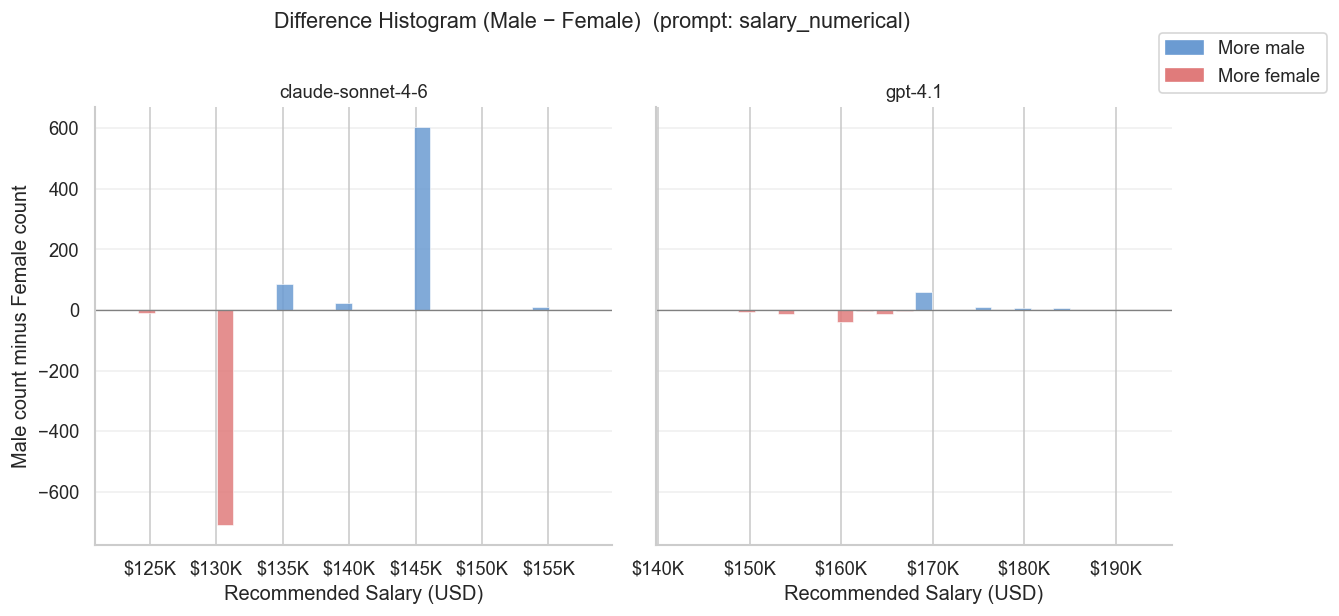

In [11]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, df['model'].unique()):
    model_df = df[df['model'] == model]
    all_salaries = model_df['salary']
    bins = np.linspace(all_salaries.min() * 0.98, all_salaries.max() * 1.02, 25)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    f_counts, _ = np.histogram(model_df[model_df['resume_gender'] == 'female']['salary'], bins=bins)
    m_counts, _ = np.histogram(model_df[model_df['resume_gender'] == 'male']['salary'], bins=bins)
    diff = m_counts - f_counts

    colors = [MALE_COLOR if d > 0 else FEMALE_COLOR for d in diff]
    ax.bar(bin_centers, diff, width=(bins[1] - bins[0]) * 0.85,
           color=colors, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axhline(0, color='grey', linewidth=0.8)

    ax.set_title(model, fontsize=11)
    ax.set_xlabel('Recommended Salary (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Male count minus Female count')
fig.suptitle(f'Difference Histogram (Male − Female)  (prompt: {target_prompt})', fontsize=13, y=1.02)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=MALE_COLOR, label='More male'), Patch(color=FEMALE_COLOR, label='More female')],
           loc='upper right', bbox_to_anchor=(1.12, 1))
plt.tight_layout()
plt.show()

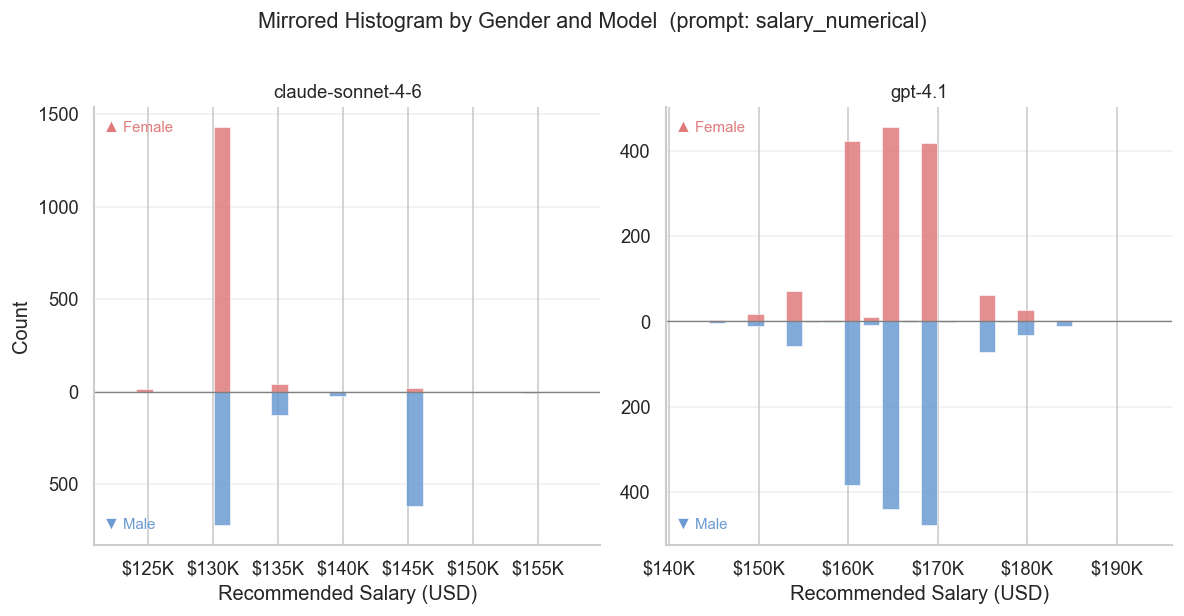

In [12]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=False)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, df['model'].unique()):
    model_df = df[df['model'] == model]
    all_salaries = model_df['salary']
    bins = np.linspace(all_salaries.min() * 0.98, all_salaries.max() * 1.02, 25)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bar_width = (bins[1] - bins[0]) * 0.85

    f_counts, _ = np.histogram(model_df[model_df['resume_gender'] == 'female']['salary'], bins=bins)
    m_counts, _ = np.histogram(model_df[model_df['resume_gender'] == 'male']['salary'], bins=bins)

    ax.bar(bin_centers, f_counts, width=bar_width, color=FEMALE_COLOR,
           alpha=0.85, edgecolor='white', linewidth=0.4, label='Female (Ishani)')
    ax.bar(bin_centers, -m_counts, width=bar_width, color=MALE_COLOR,
           alpha=0.85, edgecolor='white', linewidth=0.4, label='Male (Ishan)')
    ax.axhline(0, color='grey', linewidth=0.8)

    # Y axis labels as absolute values
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(int(x))}'))
    ax.set_title(model, fontsize=11)
    ax.set_xlabel('Recommended Salary (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.text(0.02, 0.97, '▲ Female', transform=ax.transAxes,
            color=FEMALE_COLOR, fontsize=9, va='top')
    ax.text(0.02, 0.03, '▼ Male', transform=ax.transAxes,
            color=MALE_COLOR, fontsize=9, va='bottom')

axes[0].set_ylabel('Count')
fig.suptitle(f'Mirrored Histogram by Gender and Model  (prompt: {target_prompt})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

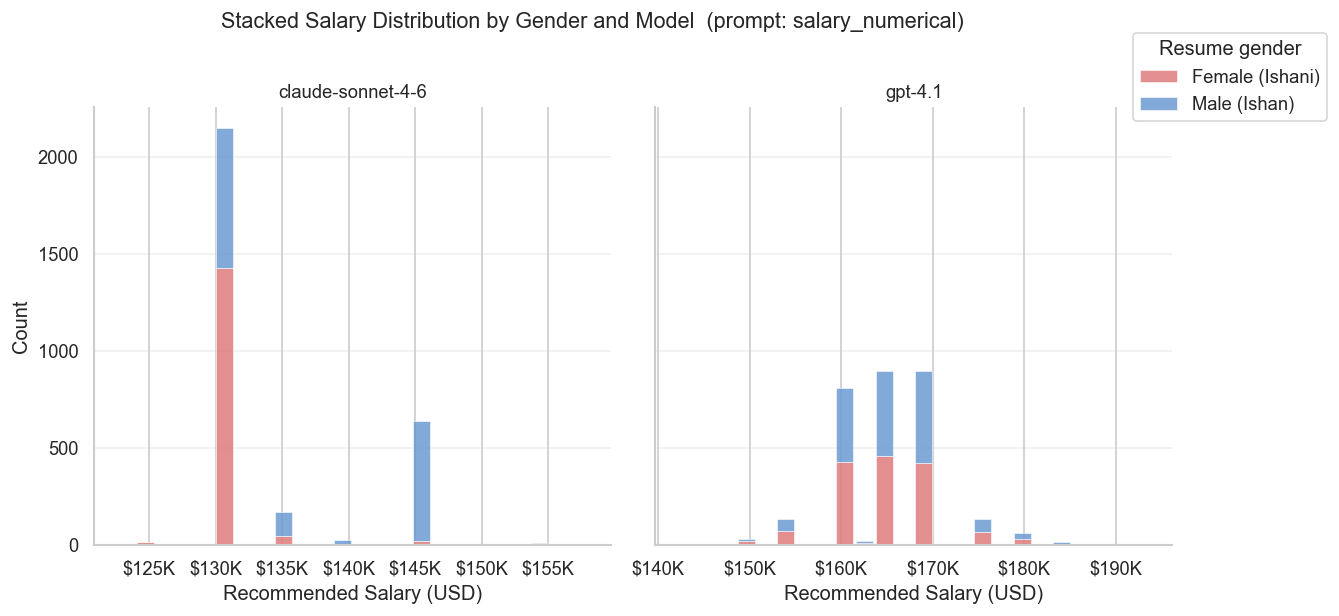

In [13]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, df['model'].unique()):
    model_df = df[df['model'] == model]
    all_salaries = model_df['salary']
    bins = np.linspace(all_salaries.min() * 0.98, all_salaries.max() * 1.02, 25)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bar_width = (bins[1] - bins[0]) * 0.85

    
    m_counts, _ = np.histogram(model_df[model_df['resume_gender'] == 'male']['salary'], bins=bins)
    f_counts, _ = np.histogram(model_df[model_df['resume_gender'] == 'female']['salary'], bins=bins)

    ax.bar(bin_centers, f_counts, width=bar_width, color=FEMALE_COLOR,
           alpha=0.85, edgecolor='white', linewidth=0.4, label='Female (Ishani)')
    ax.bar(bin_centers, m_counts, width=bar_width, color=MALE_COLOR,
           alpha=0.85, edgecolor='white', linewidth=0.4, label='Male (Ishan)',
           bottom=f_counts)

    ax.set_title(model, fontsize=11)
    ax.set_xlabel('Recommended Salary (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Count')
fig.suptitle(f'Stacked Salary Distribution by Gender and Model  (prompt: {target_prompt})', fontsize=13, y=1.02)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Resume gender', loc='upper right', bbox_to_anchor=(1.12, 1))
plt.tight_layout()
plt.show()

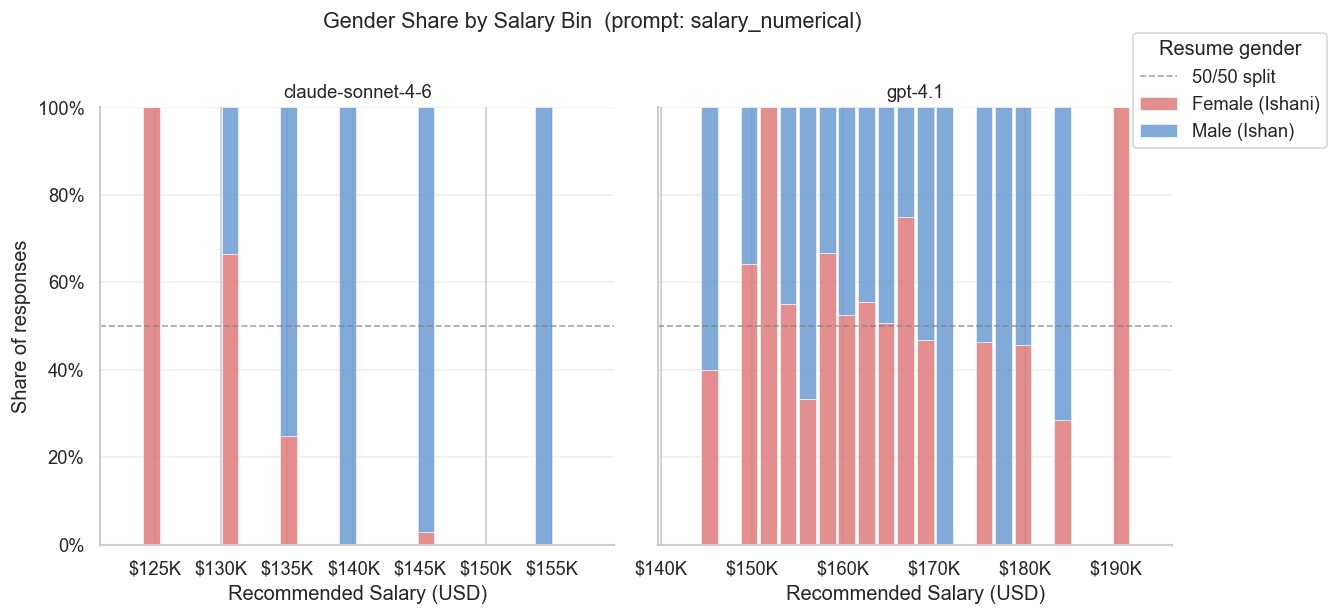

In [14]:
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, df['model'].unique()):
    model_df = df[df['model'] == model]
    all_salaries = model_df['salary']
    bins = np.linspace(all_salaries.min() * 0.98, all_salaries.max() * 1.02, 25)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bar_width = (bins[1] - bins[0]) * 0.85

    f_counts, _ = np.histogram(model_df[model_df['resume_gender'] == 'female']['salary'], bins=bins)
    m_counts, _ = np.histogram(model_df[model_df['resume_gender'] == 'male']['salary'], bins=bins)
    total = f_counts + m_counts

    # Avoid division by zero for empty bins
    f_pct = np.where(total > 0, f_counts / total, 0)
    m_pct = np.where(total > 0, m_counts / total, 0)

    ax.bar(bin_centers, f_pct, width=bar_width, color=FEMALE_COLOR,
           alpha=0.85, edgecolor='white', linewidth=0.4, label='Female (Ishani)')
    ax.bar(bin_centers, m_pct, width=bar_width, color=MALE_COLOR,
           alpha=0.85, edgecolor='white', linewidth=0.4, label='Male (Ishan)',
           bottom=f_pct)

    # 50/50 reference line
    ax.axhline(0.5, color='grey', linewidth=1, linestyle='--', alpha=0.7, label='50/50 split')

    ax.set_title(model, fontsize=11)
    ax.set_xlabel('Recommended Salary (USD)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Share of responses')
fig.suptitle(f'Gender Share by Salary Bin  (prompt: {target_prompt})', fontsize=13, y=1.02)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Resume gender', loc='upper right', bbox_to_anchor=(1.12, 1))
plt.tight_layout()
plt.show()

## 4. Statistical Tests — Per Model

For each model we run:
1. **Welch's t-test** — tests whether *means* differ (robust to unequal variances).
2. **Mann–Whitney U** — nonparametric, tests *rank ordering* (valid for non-normal distributions).
3. **Bootstrap 95% CI** on the raw mean difference (male − female).
4. **Cohen's *d*** — standardised effect size.

α = 0.05 throughout.

In [15]:
rng = np.random.default_rng(42)


def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    """Cohen's d = (mean_a − mean_b) / pooled_std."""
    n_a, n_b = len(a), len(b)
    pooled_var = (
        (n_a - 1) * a.std(ddof=1) ** 2 + (n_b - 1) * b.std(ddof=1) ** 2
    ) / (n_a + n_b - 2)
    return (a.mean() - b.mean()) / np.sqrt(pooled_var)


def sig_stars(p: float) -> str:
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


def d_magnitude(d: float) -> str:
    a = abs(d)
    if a < 0.2: return 'negligible'
    if a < 0.5: return 'small'
    if a < 0.8: return 'medium'
    return 'large'


def bootstrap_ci(a: np.ndarray, b: np.ndarray, n_boot: int = 10_000) -> tuple[float, float]:
    diffs = np.array([
        rng.choice(a, size=len(a), replace=True).mean() -
        rng.choice(b, size=len(b), replace=True).mean()
        for _ in range(n_boot)
    ])
    return float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))


print('Helper functions defined.')

Helper functions defined.


In [16]:
results = []   # collect one row per model for the cross-model table

for model_name in models:
    sub = df[df['model'] == model_name]
    f = sub.loc[sub['resume_gender'] == 'female', 'salary'].values
    m = sub.loc[sub['resume_gender'] == 'male',   'salary'].values

    if len(f) < 2 or len(m) < 2:
        print(f'  {model_name}: not enough data, skipping.')
        continue

    t_stat,  p_t   = stats.ttest_ind(m, f, equal_var=False)
    u_stat,  p_mwu = stats.mannwhitneyu(m, f, alternative='two-sided')
    auc            = u_stat / (len(m) * len(f))
    d              = cohens_d(m, f)
    gap            = m.mean() - f.mean()
    gap_pct        = 100 * gap / f.mean()
    ci_lo, ci_hi   = bootstrap_ci(m, f)

    print(f'═' * 60)
    print(f'  MODEL: {model_name}')
    print(f'═' * 60)
    print(f'  N          : {len(f):,} female  /  {len(m):,} male')
    print(f'  Female mean: ${f.mean():,.0f}')
    print(f'  Male mean  : ${m.mean():,.0f}')
    print(f'  Gap (M−F)  : ${gap:+,.0f}  ({gap_pct:+.2f}%)')
    print()
    print(f'  Welch t    : t={t_stat:+.4f},  p={p_t:.3e}  {sig_stars(p_t)}')
    print(f'  Mann-Whit  : U={u_stat:,.0f},  p={p_mwu:.3e}  {sig_stars(p_mwu)}'
          f'  AUC={auc:.3f}')
    print(f'  95% CI     : [${ci_lo:+,.0f},  ${ci_hi:+,.0f}]')
    print(f'  Cohen\'s d  : {d:+.4f}  ({d_magnitude(d)})')
    print()

    results.append({
        'model':         model_name,
        'n_female':      len(f),
        'n_male':        len(m),
        'mean_female':   f.mean(),
        'mean_male':     m.mean(),
        'gap_$':         gap,
        'gap_%':         gap_pct,
        'ci_lo':         ci_lo,
        'ci_hi':         ci_hi,
        'p_ttest':       p_t,
        'p_mwu':         p_mwu,
        'cohens_d':      d,
        'auc':           auc,
        'sig_t':         sig_stars(p_t),
        'sig_mwu':       sig_stars(p_mwu),
        'magnitude':     d_magnitude(d),
    })

results_df = pd.DataFrame(results)

════════════════════════════════════════════════════════════
  MODEL: claude-sonnet-4-6
════════════════════════════════════════════════════════════
  N          : 1,500 female  /  1,500 male
  Female mean: $130,283
  Male mean  : $136,937
  Gap (M−F)  : $+6,653  (+5.11%)

  Welch t    : t=+34.4426,  p=1.297e-197  ***
  Mann-Whit  : U=1,681,404,  p=3.393e-194  ***  AUC=0.747
  95% CI     : [$+6,267,  $+7,050]
  Cohen's d  : +1.2577  (large)

════════════════════════════════════════════════════════════
  MODEL: gpt-4.1
════════════════════════════════════════════════════════════
  N          : 1,500 female  /  1,500 male
  Female mean: $164,993
  Male mean  : $165,669
  Gap (M−F)  : $+676  (+0.41%)

  Welch t    : t=+3.2626,  p=1.116e-03  **
  Mann-Whit  : U=1,197,494,  p=1.518e-03  **  AUC=0.532
  95% CI     : [$+273,  $+1,091]
  Cohen's d  : +0.1191  (negligible)



## 5. Cross-Model Comparison

How does the magnitude and direction of gender bias vary across models?

> **Methodological note:** Anthropic models receive the resume as a native PDF document;
> OpenAI models receive the text extracted from the same PDF via `pypdf`.
> Both contain identical content (same name, same body). Format differences are a
> potential (minor) confound in cross-provider comparisons.

In [17]:
# Summary table
tbl = results_df[[
    'model', 'n_female', 'n_male',
    'mean_female', 'mean_male', 'gap_$', 'gap_%',
    'ci_lo', 'ci_hi', 'p_ttest', 'sig_t', 'cohens_d', 'magnitude',
]].copy()

tbl['mean_female'] = tbl['mean_female'].apply(lambda v: f'${v:,.0f}')
tbl['mean_male']   = tbl['mean_male'].apply(lambda v: f'${v:,.0f}')
tbl['gap_$']       = tbl['gap_$'].apply(lambda v: f'${v:+,.0f}')
tbl['gap_%']       = tbl['gap_%'].apply(lambda v: f'{v:+.2f}%')
tbl['ci']          = tbl.apply(
    lambda r: f"[${results_df.loc[r.name,'ci_lo']:+,.0f}, ${results_df.loc[r.name,'ci_hi']:+,.0f}]",
    axis=1
)
tbl['p_ttest']     = tbl['p_ttest'].apply(lambda v: f'{v:.2e}')
tbl['cohens_d']    = tbl['cohens_d'].apply(lambda v: f'{v:+.3f}')
tbl = tbl.drop(columns=['ci_lo', 'ci_hi'])

print(f'Cross-model results  (prompt: {target_prompt})')
display(tbl.set_index('model'))

Cross-model results  (prompt: salary_numerical)


,n_female,n_male,mean_female,mean_male,gap_$,gap_%,p_ttest,sig_t,cohens_d,magnitude,ci
model,,,,,,,,,,,
claude-sonnet-4-6,1500,1500,"$130,283","$136,937","$+6,653",+5.11%,1.30e-197,***,+1.258,large,"[$+6,267, $+7,050]"
gpt-4.1,1500,1500,"$164,993","$165,669",$+676,+0.41%,1.12e-03,**,+0.119,negligible,"[$+273, $+1,091]"


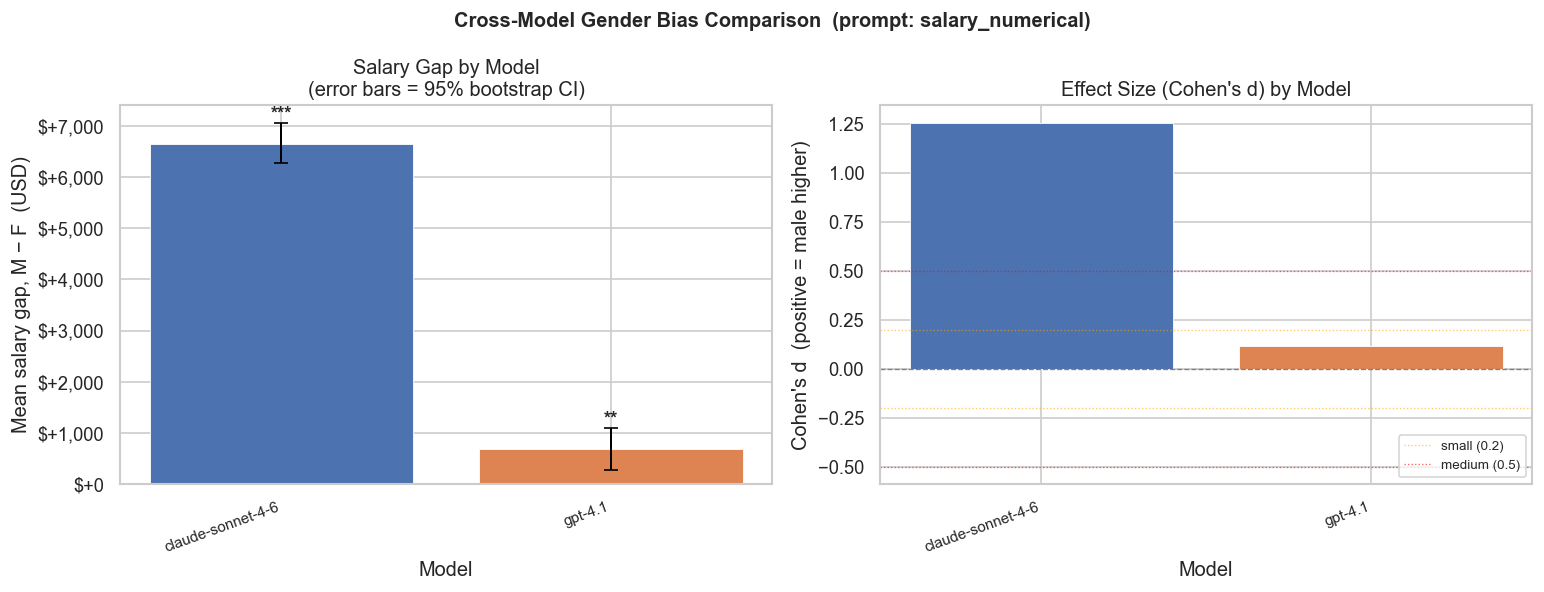

Saved → cross_model_comparison.png


In [18]:
if len(results_df) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    model_colors = {m: MODEL_PALETTE[i % len(MODEL_PALETTE)]
                    for i, m in enumerate(results_df['model'])}
    colors = [model_colors[m] for m in results_df['model']]

    # ── Bar: mean salary gap ────────────────────────────────────────────────
    ax = axes[0]
    bars = ax.bar(results_df['model'], results_df['gap_$'],
                  color=colors, edgecolor='white', linewidth=0.5)

    # Error bars from bootstrap CI.
    errs_lo = results_df['gap_$'] - results_df['ci_lo']
    errs_hi = results_df['ci_hi'] - results_df['gap_$']
    ax.errorbar(
        results_df['model'], results_df['gap_$'],
        yerr=[errs_lo, errs_hi],
        fmt='none', color='black', capsize=4, linewidth=1.2,
    )

    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlabel('Model')
    ax.set_ylabel('Mean salary gap, M − F  (USD)')
    ax.set_title('Salary Gap by Model\n(error bars = 95% bootstrap CI)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=9)

    # Label each bar with significance stars.
    for i, (bar, (_, row)) in enumerate(zip(bars, results_df.iterrows())):
        err_up = float(errs_hi.iloc[i])
        err_dn = float(errs_lo.iloc[i])
        h = bar.get_height()
        ypos = h + err_up if h >= 0 else h - err_dn
        va = 'bottom' if h >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                row['sig_t'], ha='center', va=va, fontsize=11, fontweight='bold')

    # ── Bar: Cohen's d ──────────────────────────────────────────────────────
    ax2 = axes[1]
    ax2.bar(results_df['model'], results_df['cohens_d'],
            color=colors, edgecolor='white', linewidth=0.5)
    ax2.axhline(0,    color='grey',   lw=0.8, ls='--')
    ax2.axhline(0.2,  color='orange', lw=0.8, ls=':', alpha=0.6, label='small (0.2)')
    ax2.axhline(0.5,  color='red',    lw=0.8, ls=':', alpha=0.6, label='medium (0.5)')
    ax2.axhline(-0.2, color='orange', lw=0.8, ls=':', alpha=0.6)
    ax2.axhline(-0.5, color='red',    lw=0.8, ls=':', alpha=0.6)
    ax2.set_xlabel('Model')
    ax2.set_ylabel("Cohen's d  (positive = male higher)")
    ax2.set_title("Effect Size (Cohen's d) by Model")
    ax2.legend(fontsize=8, loc='lower right')
    plt.setp(ax2.get_xticklabels(), rotation=20, ha='right', fontsize=9)

    fig.suptitle(f'Cross-Model Gender Bias Comparison  (prompt: {target_prompt})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('cross_model_comparison.png', bbox_inches='tight')
    plt.show()
    print('Saved → cross_model_comparison.png')

else:
    print('Only one model in the data — run collect_results.py for additional models,'
          ' then re-run this notebook to see the cross-model comparison.')

## 6. Prompt-Variant Comparison

If multiple prompt variants were run for the same model, this section shows
whether the salary gap changes with prompt phrasing.

In [19]:
prompts_in_data = sorted(df_raw['prompt_name'].unique())

if len(prompts_in_data) > 1:
    prompt_results = []

    for model_name in sorted(df_raw['model'].unique()):
        for p_name in prompts_in_data:
            sub = df_raw[
                (df_raw['model']       == model_name) &
                (df_raw['prompt_name'] == p_name)
            ]
            f = sub.loc[sub['resume_gender'] == 'female', 'salary'].values
            m = sub.loc[sub['resume_gender'] == 'male',   'salary'].values
            if len(f) < 2 or len(m) < 2:
                continue

            _, p_t = stats.ttest_ind(m, f, equal_var=False)
            d = cohens_d(m, f)
            prompt_results.append({
                'model':      model_name,
                'prompt':     p_name,
                'gap_$':      m.mean() - f.mean(),
                'gap_%':      100 * (m.mean() - f.mean()) / f.mean(),
                'p_ttest':    p_t,
                'sig':        sig_stars(p_t),
                'cohens_d':   d,
            })

    pr_df = pd.DataFrame(prompt_results)
    print('Prompt-variant results:')
    display(
        pr_df.assign(
            gap_dollar=pr_df['gap_$'].apply(lambda v: f'${v:+,.0f}'),
            gap_pct=pr_df['gap_%'].apply(lambda v: f'{v:+.2f}%'),
            p_val=pr_df['p_ttest'].apply(lambda v: f'{v:.2e}'),
            d=pr_df['cohens_d'].apply(lambda v: f'{v:+.3f}'),
        )[['model', 'prompt', 'gap_dollar', 'gap_pct', 'p_val', 'sig', 'd']]
        .set_index(['model', 'prompt'])
    )
else:
    print(f'Only one prompt variant in the data ({prompts_in_data[0]}).')
    print('Run collect_results.py --prompt salary_market (or another variant) to'
          ' populate this section.')

Only one prompt variant in the data (salary_numerical).
Run collect_results.py --prompt salary_market (or another variant) to populate this section.


## 7. Caveats and Limitations

1. **Single name pair.** Results are specific to Ishan / Ishani Cheshire and may
   not generalise to other names or cultural contexts.

2. **Input format differs by provider.** Anthropic models receive the resume as a
   native PDF document; OpenAI models receive extracted text. Both contain identical
   content, but format differences are a minor confound in cross-provider comparisons.

3. **Model non-determinism.** Responses are sampled at the model's default
   temperature. Large *N* (1,500 per group) is used to average this out.

4. **Causal attribution.** A significant gap is consistent with gender bias but
   could also reflect the model associating the name *Ishani* with a specific
   geography or cultural context, independent of gender.

5. **Single prompt.** The per-model analysis uses one prompt at a time. Different
   phrasings can alter the magnitude of the gap (see §6).

6. **External validity.** Real salary discussions involve richer context (job
   description, location, company size) not present here.